# F1 AI Strategy Simulator

## Step 6 — Race Simulator Engine

In this notebook we build the race simulation engine.

The simulator runs races lap-by-lap using the machine learning models
trained earlier.

Each simulated lap performs:

1. Tire age update
2. Lap time prediction
3. Pit stop decision
4. Cumulative race time update
5. Gap calculation
6. DRS detection
7. Overtake probability evaluation
8. Position update

The result is a full simulated race.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

## Load Trained Models

In [2]:
lap_model = joblib.load("../models/lap_time_model.pkl")
overtake_model = joblib.load("../models/overtake_model.pkl")
pit_model = joblib.load("../models/pit_stop_model.pkl")

print("Models loaded successfully")

Models loaded successfully


## Load Feature dataset

In [3]:
df = pd.read_csv("../data/feature_dataset.csv")

## Select race to select

In [4]:
race_df = df[df["Season"] == 2024]

race_df = race_df.sort_values(
    ["TrackEncoded","DriverEncoded","LapNumber"]
)

## Initialize Race State

In [5]:
race_state = (
    race_df
    .groupby("DriverEncoded")
    .first()
    .reset_index()
)

race_state = race_state.sort_values("Position").reset_index(drop=True)

race_state["cumulative_time"] = 0.0
race_state["lap_time"] = 0.0
race_state["pit_stop"] = False
race_state["overtake"] = False

print("Drivers in race:", len(race_state))

Drivers in race: 24


In [6]:
print("Drivers in race:", len(race_state))

Drivers in race: 24


## Simulation Parameters

In [7]:
TOTAL_LAPS = int(race_df["LapNumber"].max())

FUEL_BURN_PER_LAP = 1.7
PIT_TIME_LOSS = 20

DRS_THRESHOLD = 1.0

## Tire Degradation Model

In [8]:
def tire_penalty(age):
    return 0.03 * age + 0.002 * age**2

In [9]:
lap_features_list = lap_model.get_booster().feature_names
print(lap_features_list)

['DriverEncoded', 'TeamEncoded', 'TrackEncoded', 'Season', 'RegulationEra', 'LapNumber', 'lap_progress', 'Position', 'CompoundEncoded', 'tyre_age', 'stint_number', 'pace_trend', 'laps_since_pit', 'fuel_load', 'track_evolution', 'AirTemp', 'TrackTemp', 'Humidity', 'WindSpeed', 'gap_ahead', 'gap_behind', 'traffic_pressure', 'drs_available', 'driver_pace_baseline', 'track_pace_baseline', 'pace_relative']


## Race Simulation Loop

In [10]:
results = []

lap_features_list = [
'DriverEncoded','TeamEncoded','TrackEncoded','Season','RegulationEra',
'LapNumber','lap_progress','Position','CompoundEncoded','tyre_age',
'stint_number','pace_trend','laps_since_pit','fuel_load','track_evolution',
'AirTemp','TrackTemp','Humidity','WindSpeed','gap_ahead','gap_behind',
'traffic_pressure','drs_available','driver_pace_baseline',
'track_pace_baseline','pace_relative'
]

for lap in range(1, TOTAL_LAPS + 1):

    race_state["LapNumber"] = lap
    race_state["lap_progress"] = lap / TOTAL_LAPS

    # -----------------------------
    # Tyre aging
    # -----------------------------
    race_state["tyre_age"] += 1
    race_state["laps_since_pit"] += 1

    # -----------------------------
    # Fuel burn
    # -----------------------------
    race_state["fuel_load"] -= FUEL_BURN_PER_LAP
    race_state["fuel_load"] = race_state["fuel_load"].clip(lower=0)

    # -----------------------------
    # Track evolution
    # -----------------------------
    race_state["track_evolution"] = lap / TOTAL_LAPS

    # -----------------------------
    # Ensure required columns exist
    # -----------------------------
    for col in ["AirTemp","TrackTemp","Humidity","WindSpeed",
                "gap_ahead","gap_behind","traffic_pressure",
                "drs_available"]:
        if col not in race_state.columns:
            race_state[col] = 0

    if "RegulationEra" not in race_state.columns:
        race_state["RegulationEra"] = 1

    # =============================
    # LAP TIME MODEL
    # =============================

    lap_features = race_state[lap_features_list].fillna(0)

    race_state["lap_time"] = lap_model.predict(lap_features)

    # realistic lap bounds
    race_state["lap_time"] = race_state["lap_time"].clip(70,120)

    # fuel weight
    fuel_effect = race_state["fuel_load"] * 0.03
    race_state["lap_time"] += fuel_effect

    # =============================
    # TEAM PERFORMANCE DELTA
    # =============================

    team_strength = ((race_state["TeamEncoded"] % 5) - 2) * 0.12
    race_state["lap_time"] += team_strength

    # =============================
    # DRIVER VARIABILITY
    # =============================

    driver_error = np.random.normal(0,0.35,len(race_state))
    driver_error = np.clip(driver_error,-0.8,0.8)

    race_state["lap_time"] += driver_error

    # =============================
    # DIRTY AIR
    # =============================

    dirty_air = np.where(
        race_state["gap_ahead"] < 1.5,
        0.25,
        0
    )

    race_state["lap_time"] += dirty_air

    # =============================
    # DRS BOOST
    # =============================

    drs_boost = np.where(
        race_state["drs_available"] == 1,
        -0.15,
        0
    )

    race_state["lap_time"] += drs_boost

    # =============================
    # PIT STRATEGY FEATURES
    # =============================

    race_state["compound_stint_age"] = race_state["CompoundEncoded"] * race_state["tyre_age"]

    race_state["pit_window_pressure"] = (
        race_state["laps_since_pit"] /
        (race_state["laps_since_pit"] + 10)
    )

    race_state["pace_drop"] = (
        race_state["pace_trend"] -
        race_state["driver_pace_baseline"]
    )

    race_state["stint_progress"] = (
        race_state["laps_since_pit"] /
        (race_state["laps_since_pit"].max() + 1)
    )

    race_state["undercut_pressure"] = (race_state["gap_ahead"] < 2).astype(int)

    if "track_pit_rate" not in race_state.columns:
        race_state["track_pit_rate"] = 0.05

    # =============================
    # PIT MODEL
    # =============================

    pit_features = race_state[
    [
    "DriverEncoded","TrackEncoded","Season","Position",
    "CompoundEncoded","tyre_age","stint_number",
    "laps_since_pit","stint_progress","pace_trend",
    "pace_drop","fuel_load","track_evolution",
    "gap_ahead","gap_behind","traffic_pressure",
    "undercut_pressure","compound_stint_age",
    "track_pit_rate","pit_window_pressure"
    ]
    ].fillna(0)

    pit_prob = pit_model.predict_proba(pit_features)[:,1]

    race_state["pit_stop"] = (
        (np.random.rand(len(race_state)) < pit_prob) &
        (race_state["tyre_age"] > 8)
    )

    race_state.loc[race_state["pit_stop"],"lap_time"] += PIT_TIME_LOSS
    race_state.loc[race_state["pit_stop"],"tyre_age"] = 0
    race_state.loc[race_state["pit_stop"],"laps_since_pit"] = 0
    race_state.loc[race_state["pit_stop"],"stint_number"] += 1

    # =============================
    # UPDATE RACE TIME
    # =============================

    race_state["cumulative_time"] += race_state["lap_time"]

    # =============================
    # SORT POSITIONS
    # =============================

    race_state = race_state.sort_values("cumulative_time").reset_index(drop=True)
    race_state["Position"] = np.arange(1,len(race_state)+1)

    # =============================
    # GAP CALCULATION
    # =============================

    race_state["gap_ahead"] = (
        race_state["cumulative_time"] -
        race_state["cumulative_time"].shift(1)
    ).fillna(0)

    race_state["gap_behind"] = (
        race_state["cumulative_time"].shift(-1) -
        race_state["cumulative_time"]
    ).fillna(0)

    race_state["traffic_pressure"] = race_state["gap_ahead"] - race_state["gap_behind"]

    race_state["gap_ahead"] = race_state["gap_ahead"].clip(0,10)
    race_state["gap_behind"] = race_state["gap_behind"].clip(0,10)

    # =============================
    # DRS
    # =============================

    race_state["drs_available"] = (race_state["gap_ahead"] < DRS_THRESHOLD).astype(int)

    # =============================
    # OVERTAKE FEATURES
    # =============================

    race_state["pace_diff"] = race_state["pace_trend"].diff().fillna(0)
    race_state["tyre_advantage"] = race_state["tyre_age"].diff().fillna(0)

    race_state["close_battle"] = (race_state["gap_ahead"] < 1.2).astype(int)

    race_state["closing_speed"] = (
        race_state["gap_ahead"].shift(1) -
        race_state["gap_ahead"]
    ).fillna(0).clip(-3,3)

    race_state["drs_pressure"] = (
        race_state["drs_available"] *
        np.maximum(0,1-race_state["gap_ahead"])
    )

    if "track_overtake_rate" not in race_state.columns:
        race_state["track_overtake_rate"] = 0.15

    # =============================
    # OVERTAKE MODEL
    # =============================

    overtake_features = race_state[
    [
    "DriverEncoded","TrackEncoded","Season","Position",
    "CompoundEncoded","tyre_age","pace_trend",
    "gap_ahead","gap_behind","traffic_pressure",
    "laps_since_pit","drs_available",
    "pace_diff","tyre_advantage","close_battle",
    "closing_speed","drs_pressure","track_overtake_rate"
    ]
    ].fillna(0)

    overtake_prob = overtake_model.predict_proba(overtake_features)[:,1]

    race_state["overtake"] = np.random.rand(len(race_state)) < overtake_prob

    # =============================
    # APPLY OVERTAKES
    # =============================

    for i in range(1,len(race_state)):
        if race_state.loc[i,"overtake"] and race_state.loc[i,"gap_ahead"] < 1.2:
            race_state.iloc[[i-1,i]] = race_state.iloc[[i,i-1]].values

    lap_state = race_state.copy()
    lap_state["LapNumber"] = lap

    results.append(lap_state)

## Combine Simulation Results

In [11]:
simulation = pd.concat(results)

In [12]:
print(race_state.shape)
print(race_state.head())

(24, 44)
   DriverEncoded  TeamEncoded  TrackEncoded  Season  RegulationEra  LapNumber  \
0              1           16             0    2024              1         78   
1             38            7             0    2024              1         78   
2             32            5             0    2024              1         78   
3              6            7             0    2024              1         78   
4             26            3             0    2024              1         78   

   lap_progress  Position  CompoundEncoded  tyre_age  ...  pace_drop  \
0           1.0         1              1.0      22.0  ...  16.688615   
1           1.0         2              1.0      39.0  ...  17.359078   
2           1.0         4              1.0      32.0  ...   8.618025   
3           1.0         3              1.0      28.0  ...  17.216808   
4           1.0         5              1.0      34.0  ...  17.397137   

   stint_progress  undercut_pressure  track_pit_rate  pace_diff  \
0   

## Final Race Results

In [13]:
final_results = simulation[simulation["LapNumber"] == TOTAL_LAPS]

final_results = final_results.sort_values("Position")

final_results[["DriverEncoded","Position","cumulative_time"]]

,DriverEncoded,Position,cumulative_time
0,1,1,5568.129499
1,38,2,5584.141316
3,6,3,5588.618004
2,32,4,5588.786420
4,26,5,5591.721963
5,30,6,5594.807046
6,7,7,5599.206656
7,20,8,5603.729946
8,21,9,5608.511487
11,25,10,5613.092130


## Race Position Evolution

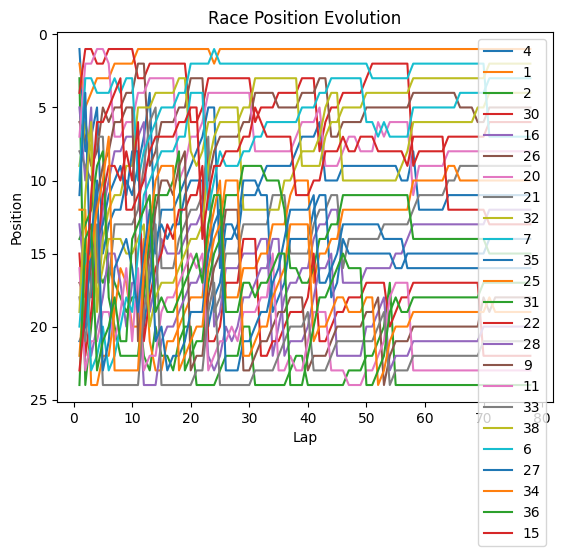

In [14]:
for driver in simulation["DriverEncoded"].unique():

    d = simulation[simulation["DriverEncoded"] == driver]

    plt.plot(d["LapNumber"], d["Position"], label=driver)

plt.gca().invert_yaxis()

plt.xlabel("Lap")
plt.ylabel("Position")
plt.title("Race Position Evolution")

plt.legend()

plt.show()

In [15]:
simulation.to_csv("../data/race_simulation_results.csv", index=False)

print("Simulation saved successfully.")

Simulation saved successfully.


In [16]:
print(final_results.iloc[0]["cumulative_time"])

5568.1294993448055
